# 02 Q2 Routing Control

LaTeX position:

- `fig:routing-control-panels`

This version keeps one direct quality panel, one compact stage-averaged group profile, and one compact case panel.

What this figure should prove:

- Panel (a): the routing source matters for ranking quality within each dataset.
- Panel (b): behavior groups still separate cleanly even after averaging over the 3 routing stages.
- Panel (c): a few representative cases also split differently inside one semantic family even after stage averaging.

In [ ]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path('/workspace/FeaturedMoE/writing/260418_final_exp_figure')
DATA_DIR = ROOT / 'data'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import slot_viz_helpers as viz
importlib.reload(viz)

from slot_viz_helpers import (
    category_bar_line_plot,
    heatmap_panel,
    setup_style,
)

setup_style()


def pivot_metric_frame(df, id_cols, metric_map):
    wide = df.pivot_table(index=id_cols, columns=['metric', 'cutoff'], values='value', aggfunc='first').reset_index()
    flattened = []
    for col in wide.columns:
        if isinstance(col, tuple):
            left, right = col
            if right == '':
                flattened.append(left)
            elif left == '':
                flattened.append(str(right))
            else:
                flattened.append(f"{left}_{right}")
        else:
            flattened.append(col)
    wide.columns = flattened
    rename_map = {}
    for new_name, (metric, cutoff) in metric_map.items():
        rename_map[f"{metric}_{cutoff}"] = new_name
    wide = wide.rename(columns=rename_map)
    for new_name in metric_map:
        if new_name not in wide.columns:
            wide[new_name] = np.nan
    return wide


def show_status_notes(df, placeholder_note=None, ready_note=None):
    if 'status' not in df.columns:
        return
    status_series = df['status'].dropna().astype(str)
    if status_series.empty:
        return
    if status_series.str.contains('placeholder', case=False).any() and placeholder_note:
        display(Markdown(placeholder_note))
    elif ready_note:
        display(Markdown(ready_note))

quality_df = pd.read_csv(DATA_DIR / '02_routing_quality.csv')
profile_df = pd.read_csv(DATA_DIR / '02_routing_group_profile.csv')
intragroup_df = pd.read_csv(DATA_DIR / '02_routing_intragroup_profile.csv')

### (a) Ranking quality by dataset

**Export path**: this panel is already aligned with the final summary schema used for routing-control exports.

Required export columns: dataset, variant_or_model, metric, cutoff, value, split, selection_rule, run_id
Display rule: each dataset gets its own axis, and variants are compared inside that dataset.


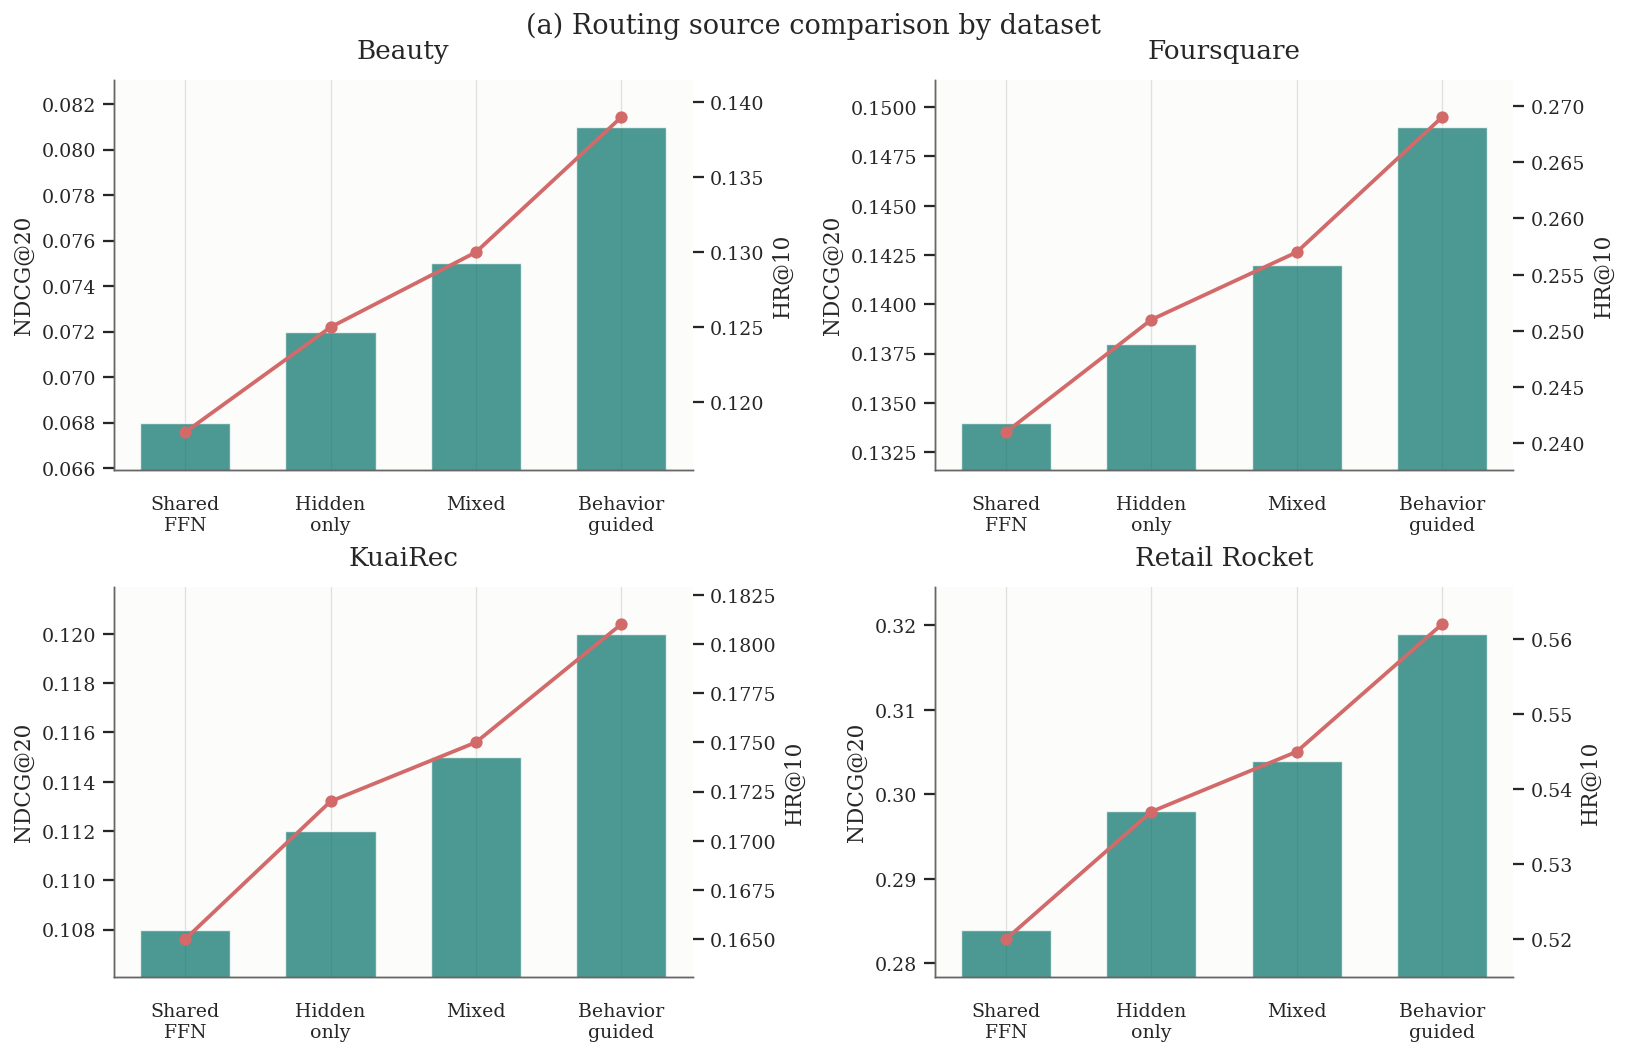

In [ ]:
display(Markdown('### (a) Ranking quality by dataset'))
show_status_notes(
    quality_df,
    placeholder_note='**Template status**: current rows are draft-fill values. Replace them with the final export from the routing-control summary CSV once the confirm runs finish.',
    ready_note='**Export path**: this panel is already aligned with the final summary schema used for routing-control exports.',
)
print('Required export columns: dataset, variant_or_model, metric, cutoff, value, split, selection_rule, run_id')
print('Display rule: each dataset gets its own axis, and variants are compared inside that dataset.')

quality_plot_df = pivot_metric_frame(
    quality_df,
    id_cols=['dataset', 'variant_or_model'],
    metric_map={'ndcg20': ('NDCG', 20), 'hr10': ('HR', 10)},
).rename(columns={'variant_or_model': 'variant'})

variant_order = ['shared_ffn', 'hidden_only', 'mixed_hidden_behavior', 'behavior_guided']
variant_label_map = {
    'shared_ffn': 'Shared\nFFN',
    'hidden_only': 'Hidden\nonly',
    'mixed_hidden_behavior': 'Mixed',
    'behavior_guided': 'Behavior\nguided',
}
datasets = ['Beauty', 'Foursquare', 'KuaiRec', 'Retail Rocket']

fig, axes = plt.subplots(2, 2, figsize=(12.4, 7.8), constrained_layout=True)
for axis, dataset in zip(axes.flat, datasets):
    dataset_plot_df = quality_plot_df[quality_plot_df['dataset'] == dataset].copy()
    category_bar_line_plot(
        dataset_plot_df,
        category_col='variant',
        bar_col='ndcg20',
        line_col='hr10',
        ax=axis,
        title=dataset,
        ylabel='NDCG@20',
        xlabel='',
        line_label='HR@10',
        order=variant_order,
        category_labels=variant_label_map,
        rotate=0,
    )
    axis.tick_params(axis='x', pad=8)

fig.suptitle('(a) Routing source comparison by dataset', y=1.02, fontsize=15)
plt.show()

### (b) Stage-averaged group routing profile

**Template status**: this panel uses placeholder group-level routing profiles. To fill it with real values, keep `fmoe_diag_logging=true` and export per-session stage-level expert usage before aggregation.

Needed logging for a real panel: dataset, session_id, split, stage, expert_family, expert_weight, repeat_ratio, switch_rate, focus_entropy, mean_gap
Aggregation target for the main text: mean expert usage by (behavior_group, expert_family) after averaging over the 3 stages.


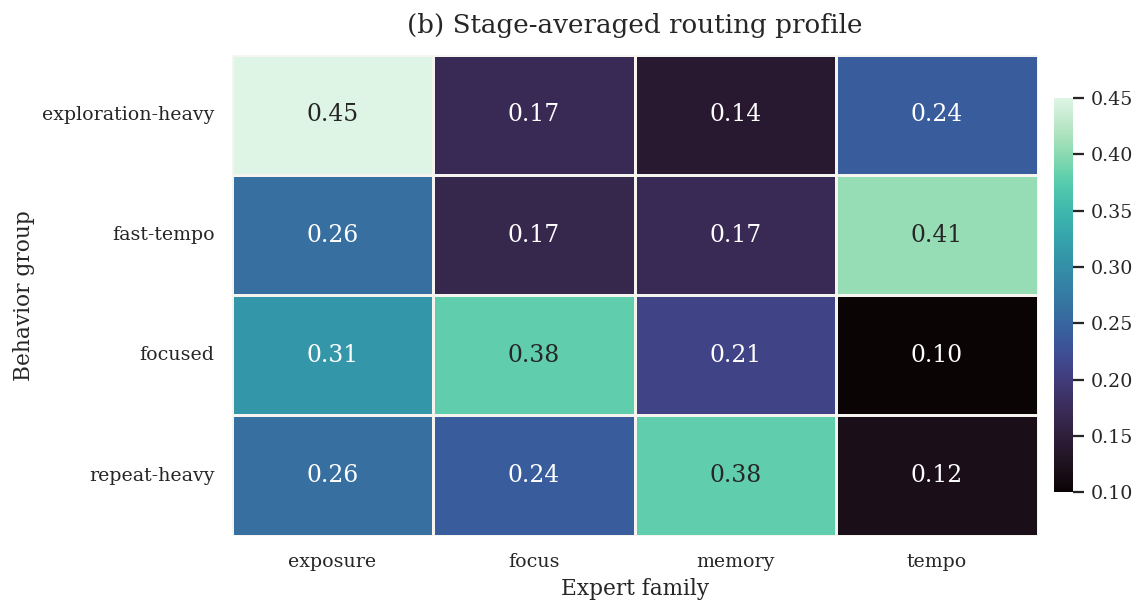

In [ ]:
display(Markdown('### (b) Stage-averaged group routing profile'))
show_status_notes(
    profile_df,
    placeholder_note='**Template status**: this panel uses placeholder group-level routing profiles. To fill it with real values, keep `fmoe_diag_logging=true` and export per-session stage-level expert usage before aggregation.',
)
print('Needed logging for a real panel: dataset, session_id, split, stage, expert_family, expert_weight, repeat_ratio, switch_rate, focus_entropy, mean_gap')
print('Aggregation target for the main text: mean expert usage by (behavior_group, expert_family) after averaging over the 3 stages.')

profile_plot_df = (
    profile_df
    .groupby(['behavior_group', 'expert_family'], as_index=False)['usage']
    .mean()
)

fig, ax = plt.subplots(figsize=(8.7, 4.6), constrained_layout=True)
heatmap_panel(
    profile_plot_df,
    index='behavior_group',
    columns='expert_family',
    values='usage',
    ax=ax,
    title='(b) Stage-averaged routing profile',
    cmap='mako',
    fmt='.2f',
)
ax.set_xlabel('Expert family')
ax.set_ylabel('Behavior group')
plt.show()

### (c) Stage-averaged representative cases

**Template status**: this panel stays placeholder until representative sessions are selected and within-family expert weights are exported for each stage.

This panel should stay compact but more diverse: average over macro, mid, and micro first, then compare several representative cases.
Recommended mix: repeat-heavy, focused, fast-tempo, and exploratory sessions so the semantic families feel distinct.
Needed logging: case_name, stage, expert_group, expert_member, expert_weight, plus a short textual case description outside the plot.


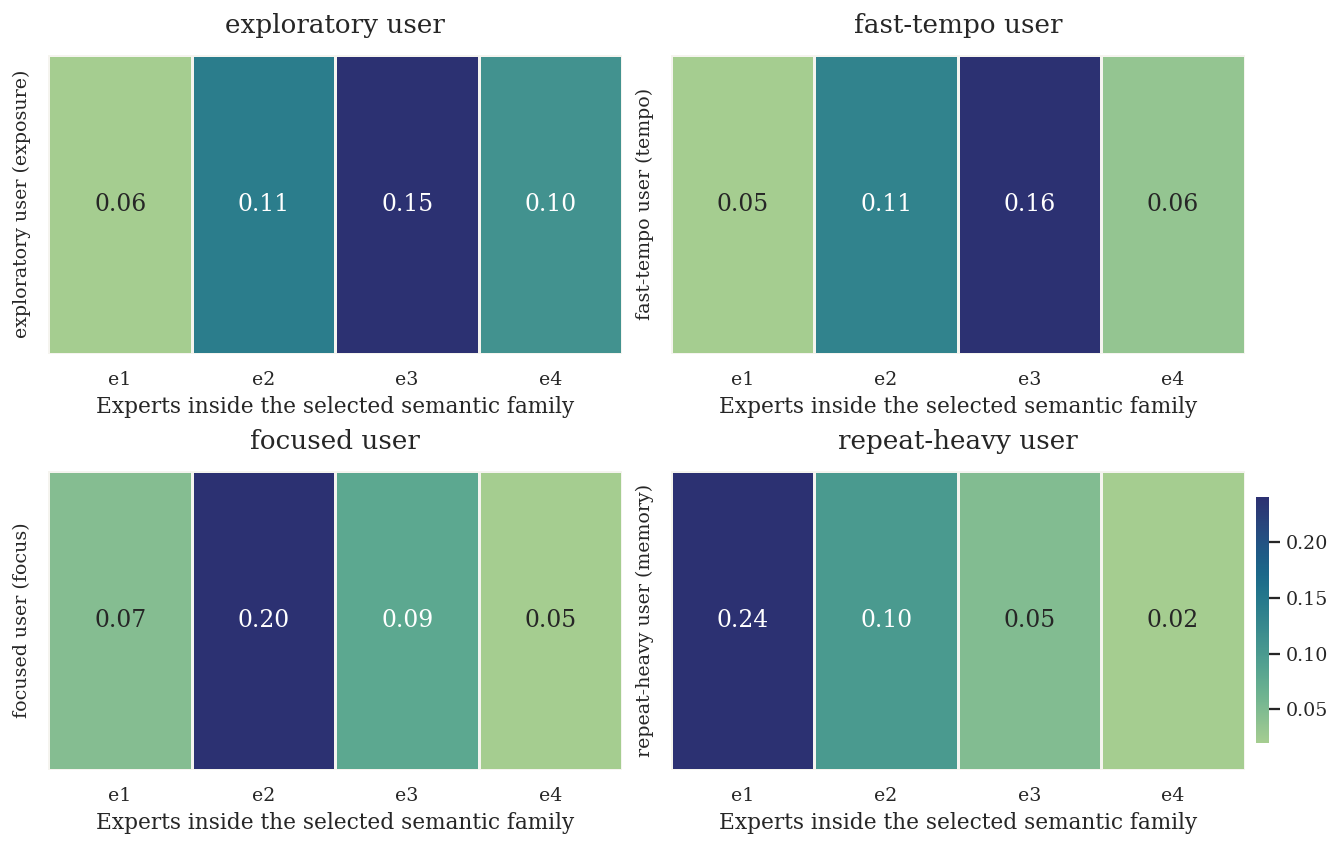

In [ ]:
display(Markdown('### (c) Stage-averaged representative cases'))
show_status_notes(
    intragroup_df,
    placeholder_note='**Template status**: this panel stays placeholder until representative sessions are selected and within-family expert weights are exported for each stage.',
)
print('This panel should stay compact but more diverse: average over macro, mid, and micro first, then compare several representative cases.')
print('Recommended mix: repeat-heavy, focused, fast-tempo, and exploratory sessions so the semantic families feel distinct.')
print('Needed logging: case_name, stage, expert_group, expert_member, expert_weight, plus a short textual case description outside the plot.')

intragroup_plot_df = (
    intragroup_df
    .groupby(['case_name', 'expert_group', 'expert_member'], as_index=False)['usage']
    .mean()
)
intragroup_plot_df['case_label'] = intragroup_plot_df['case_name'] + ' (' + intragroup_plot_df['expert_group'] + ')'

cases = intragroup_plot_df['case_name'].drop_duplicates().tolist()
ncols = 2
nrows = int(np.ceil(len(cases) / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(10.2, 2.8 * nrows + 0.8),
    constrained_layout=True,
 )
axes = np.atleast_1d(axes).ravel()

for axis, case_name in zip(axes, cases):
    case_df = intragroup_plot_df[intragroup_plot_df['case_name'] == case_name].copy()
    heatmap_panel(
        case_df,
        index='case_label',
        columns='expert_member',
        values='usage',
        ax=axis,
        title=case_name,
        cmap='crest',
        fmt='.2f',
        cbar=(case_name == cases[-1]),
    )
    axis.set_xlabel('Experts inside the selected semantic family')
    axis.set_ylabel('')

for axis in axes[len(cases):]:
    axis.axis('off')

plt.show()